In [1]:
#Time series analysis on flights dataset from Seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import math

df = sns.load_dataset('flights')
print(df.head())
#Converting it to a specified date-time format
df['yearMonth'] = pd.to_datetime("01-"+df['month'].astype(str)+'-'+df['year'].astype(str))
df.set_index('yearMonth',inplace=True)

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


In [2]:
df.head()

,year,month,passengers
yearMonth,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


In [3]:
#Copy the apssengers column inti a new df for more analysis
airP = df[['passengers']].copy(deep=True)
print(airP)

            passengers
yearMonth             
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]


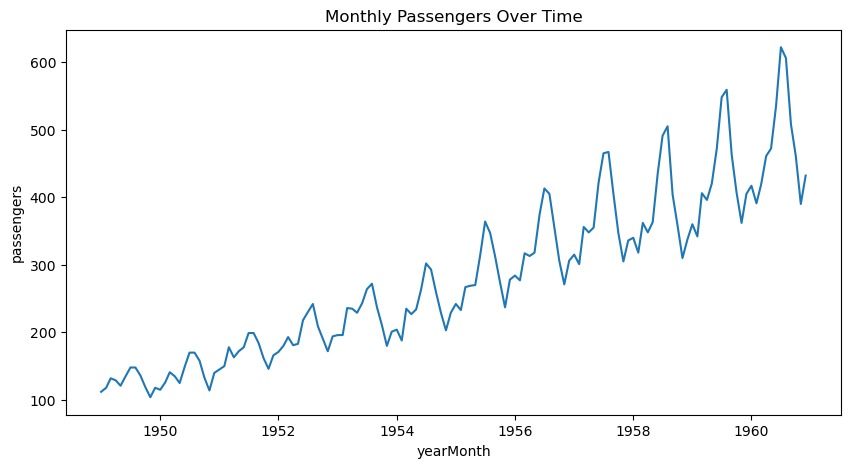

In [4]:
#Visualize initial Data 
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index,y=airP['passengers'])
plt.title("Monthly Passengers Over Time")
plt.show()

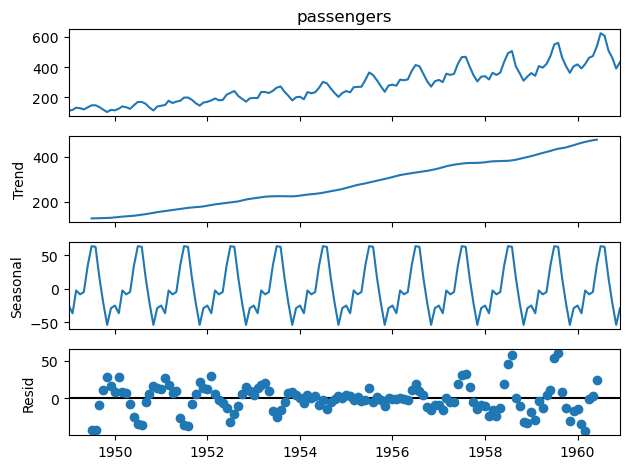

In [5]:
#Decompose to Check TRend and Seasonality
decomposition = seasonal_decompose(airP.passengers,period=12)
decomposition.plot()
plt.show()

In [6]:
# Conversion of Non-Stationary Data Into Stationary Data :
#Stationary data looks stable over time 
# Dont try the prediction on non stationary data. One clue to convert the data into stationary form is to take the moving mean 
# of the differences of the frquencies which generally limits the range.


In [7]:
#Stationary Check 
def test_stationary(dataFrame,var,window=12):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]
    
    print(f"ADF p-value : {p_value:4f}")
    if p_value < 0.05: 
        print("The time series is ststionary (reject H0)")
    else:
        print("Failed to reject  ! The time series is not stationary ")
    
    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.index,y=dataFrame[var],label='Original')
    sns.lineplot(x=dataFrame.index,y=dataFrame['rollMean'],label='Roll Mean')
    sns.lineplot(x=dataFrame.index,y=dataFrame['rollStd'],label='Roll STD')
    plt.title("Rolling Statistics")
    plt.legend()
    plt.show()


ADF p-value : 0.991880
Failed to reject  ! The time series is not stationary 


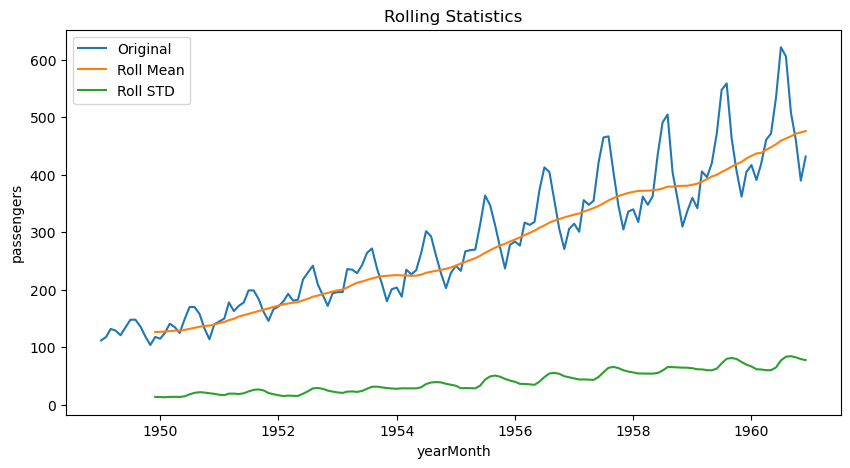

In [8]:
#Test Stationarity
test_stationary(airP,'passengers')

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN  112.0        6.0
1949-03-01         132         NaN        NaN  118.0       14.0
1949-04-01         129         NaN        NaN  132.0       -3.0
1949-05-01         121         NaN        NaN  129.0       -8.0
1949-06-01         135         NaN        NaN  121.0       14.0
1949-07-01         148         NaN        NaN  135.0       13.0
1949-08-01         148         NaN        NaN  148.0        0.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  136.0      -17.0
1949-11-01         104         NaN        NaN  119.0      -15.0
1949-12-01         118  126.666667  13.720147  104.0       14.0
1950-01-01         115  126.916667  13.453342  118.0       -3.0
1950-02-01         126  127.583333  13.1

C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_5232\2333076326.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_5232\2333076326.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()


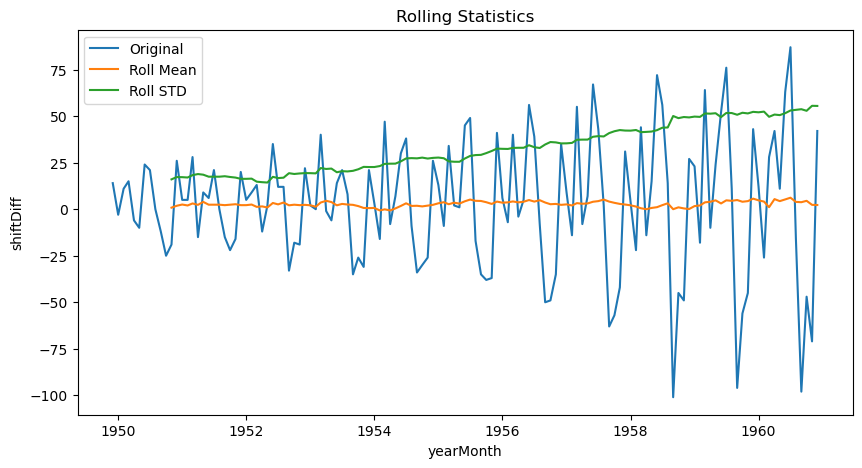

In [9]:
airP['shift'] = airP.passengers.shift(1)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP.head(20))
test_stationary(airP.dropna(),'shiftDiff')

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN    NaN        NaN
1949-03-01         132         NaN        NaN  112.0       20.0
1949-04-01         129         NaN        NaN  118.0       11.0
1949-05-01         121         NaN        NaN  132.0      -11.0
1949-06-01         135         NaN        NaN  129.0        6.0
1949-07-01         148         NaN        NaN  121.0       27.0
1949-08-01         148         NaN        NaN  135.0       13.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  148.0      -29.0
1949-11-01         104         NaN        NaN  136.0      -32.0
1949-12-01         118  126.666667  13.720147  119.0       -1.0
1950-01-01         115  126.916667  13.453342  104.0       11.0
1950-02-01         126  127.583333  13.1

C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_5232\2333076326.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_5232\2333076326.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()


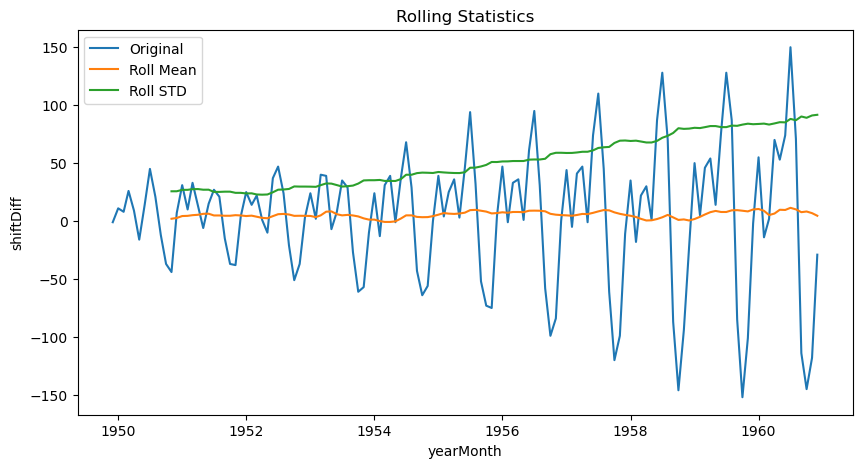

In [10]:
airP['shift'] = airP.passengers.shift(2)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP.head(20))
test_stationary(airP.dropna(),'shiftDiff')

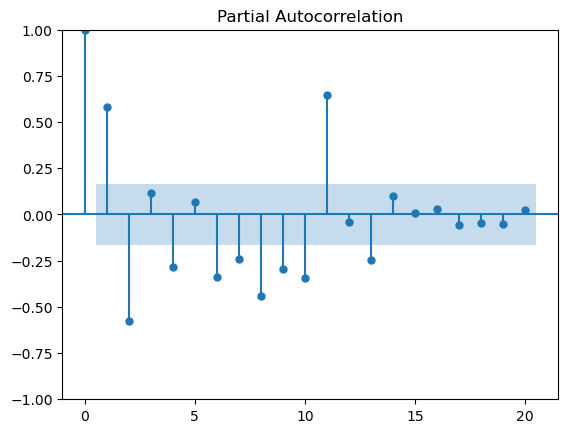

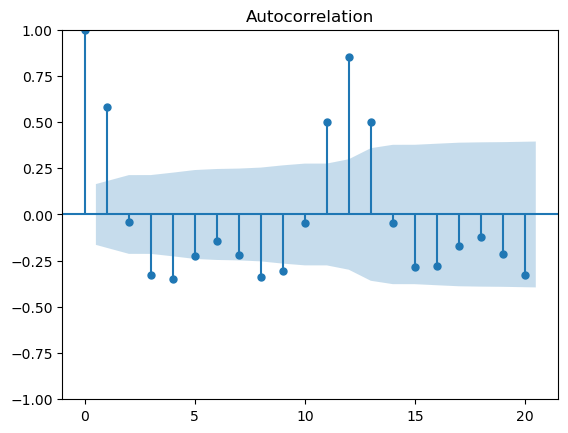

In [11]:
#For ACF - Differnecing of 2 and 12
airP['secondDiff'] = airP['passengers'].diff(2)
airP['Diff12'] = airP['passengers'].diff(12)

#PACF and ACF plots
plot_pacf(airP['secondDiff'].dropna(),lags=20)
plt.show()

plot_acf(airP['secondDiff'].dropna(),lags=20)
plt.show()

            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1960-08-01         606  463.333333  83.630500  535.0       71.0        71.0   
1960-09-01         508  467.083333  84.617276  622.0     -114.0      -114.0   
1960-10-01         461  471.583333  82.541954  606.0     -145.0      -145.0   
1960-11-01         390  473.916667  79.502382  508.0     -118.0      -118.0   
1960-12-01         432  476.166667  77.737125  461.0      -29.0       -29.0   

            Diff12   arimaPred  
yearMonth                       
1960-08-01    47.0  439.708772  
1960-09-01    45.0  442.074518  
1960-10-01    54.0  444.440264  
1960-11-01    28.0  446.806009  
1960-12-01    27.0  449.171755  


C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


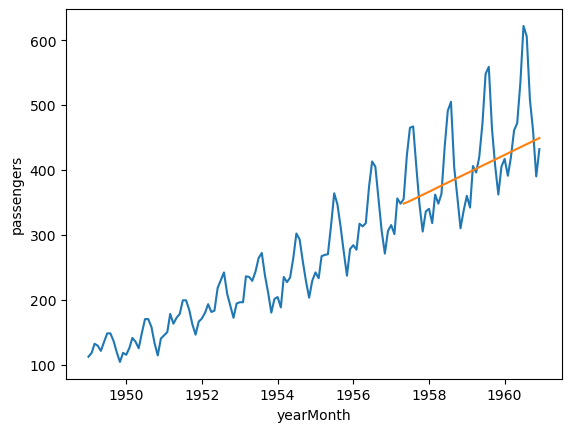

Through the graph we declare the arima predictions are poor


In [12]:
#Test-Train Split

train_size = int(len(airP) * 0.7)
train = airP.iloc[:train_size]
test = airP.iloc[train_size:]

#ARIMA Model
model_arima = ARIMA(train['passengers'],order=(1,2,1))
model_arima_fit = model_arima.fit()
arima_pred = model_arima_fit.predict(start=len(train),end = len(airP)-1)

#Add ARIMA prediction to dataFrame
airP['arimaPred'] = np.nan
airP.iloc[train_size:,airP.columns.get_loc('arimaPred')] = arima_pred.values
print(airP.tail())

#Plot
sns.lineplot(data=airP,x=airP.index,y='passengers')
sns.lineplot(data=airP,x=airP.index,y='arimaPred')

plt.show()

print("Through the graph we declare the arima predictions are poor")

#### Sarimax 

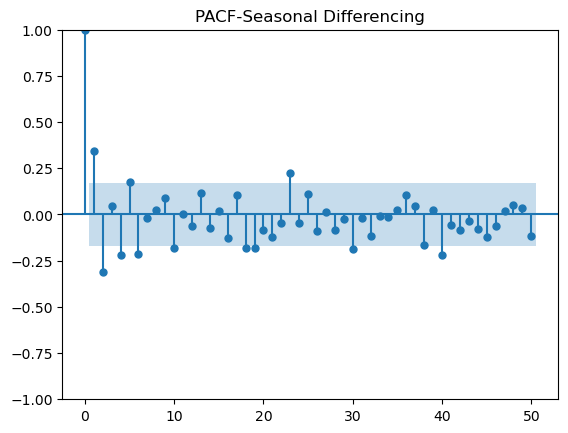

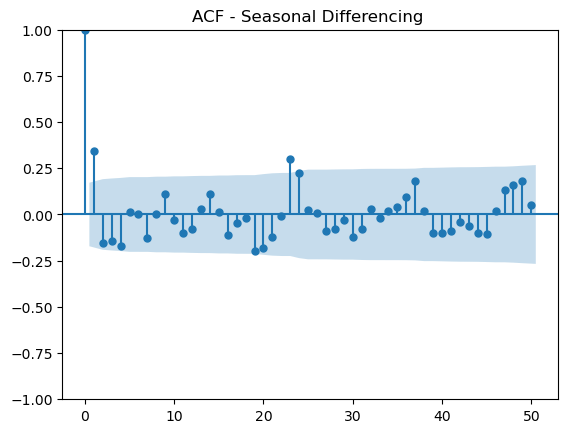

In [13]:

airP['diff_combined'] = airP['passengers'].diff(2).diff(12)

plot_pacf(airP['diff_combined'].dropna(),lags=50)
plt.title("PACF-Seasonal Differencing")
plt.show()

plot_acf(airP['diff_combined'].dropna(),lags=50)
plt.title("ACF - Seasonal Differencing ")
plt.show()

In [14]:
model_sarimax = SARIMAX(train['passengers'],order=(1,2,1),seasonal_order=(1,2,1,12))
model_sarimax_fit = model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start=len(train),end=len(airP)-1)


C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [15]:
#Add SARIMAX prediction to DataFrame 
airP['sarimaxPred'] = np.nan
airP.iloc[train_size:,airP.columns.get_loc('sarimaxPred')] = sarimax_pred.values
print(airP.tail())

            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1960-08-01         606  463.333333  83.630500  535.0       71.0        71.0   
1960-09-01         508  467.083333  84.617276  622.0     -114.0      -114.0   
1960-10-01         461  471.583333  82.541954  606.0     -145.0      -145.0   
1960-11-01         390  473.916667  79.502382  508.0     -118.0      -118.0   
1960-12-01         432  476.166667  77.737125  461.0      -29.0       -29.0   

            Diff12   arimaPred  diff_combined  sarimaxPred  
yearMonth                                                   
1960-08-01    47.0  439.708772          -16.0   594.456219  
1960-09-01    45.0  442.074518          -29.0   524.213254  
1960-10-01    54.0  444.440264            7.0   458.555300  
1960-11-01    28.0  446.806009          -17.0   408.918183  
1960-12-01    27.0  449.171755          -27.0   457.026490  


            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1957-05-01         355  342.083333  43.324271  356.0       -1.0        -1.0   
1957-06-01         422  346.083333  48.451397  348.0       74.0        74.0   
1957-07-01         465  350.416667  56.617470  355.0      110.0       110.0   
1957-08-01         467  355.583333  64.351956  422.0       45.0        45.0   
1957-09-01         404  359.666667  65.848771  465.0      -61.0       -61.0   

            Diff12   arimaPred  diff_combined  sarimaxPred  
yearMonth                                                   
1957-05-01    37.0  348.086876           -2.0   356.064865  
1957-06-01    48.0  349.951620           13.0   415.079097  
1957-07-01    52.0  352.207223           15.0   462.365169  
1957-08-01    62.0  354.548754           14.0   449.225030  
1957-09-01    49.0  356.909176           -3.0   396.623902  


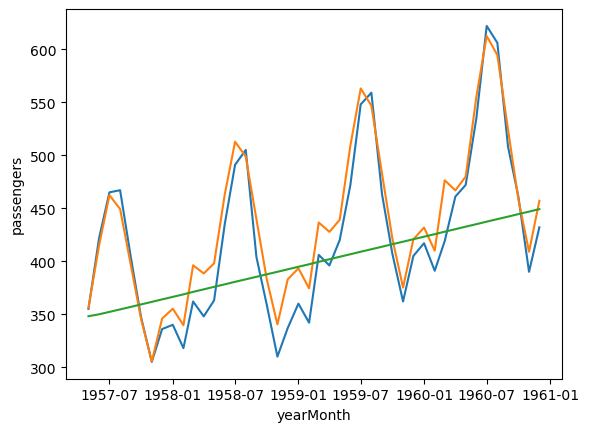

In [16]:
#PLot 
airP = airP.dropna()
print(airP.head())
sns.lineplot(data=airP,x=airP.index,y='passengers')
sns.lineplot(data=airP,x=airP.index,y='sarimaxPred')
sns.lineplot(data=airP,x=airP.index,y='arimaPred')
plt.show()

1961-01-01    468.924576
1961-02-01    444.061383
1961-03-01    515.018892
1961-04-01    504.539580
1961-05-01    519.266367
1961-06-01    599.651553
1961-07-01    660.635596
1961-08-01    640.470634
1961-09-01    564.483323
1961-10-01    494.146303
1961-11-01    440.984014
1961-12-01    491.725877
1962-01-01    504.306813
1962-02-01    476.344343
1962-03-01    551.704968
1962-04-01    540.269444
1962-05-01    556.574461
1962-06-01    642.020817
1962-07-01    706.522576
1962-08-01    684.264824
1962-09-01    602.439945
1962-10-01    527.340919
1962-11-01    470.609974
1962-12-01    523.894611
Freq: MS, Name: predicted_mean, dtype: float64


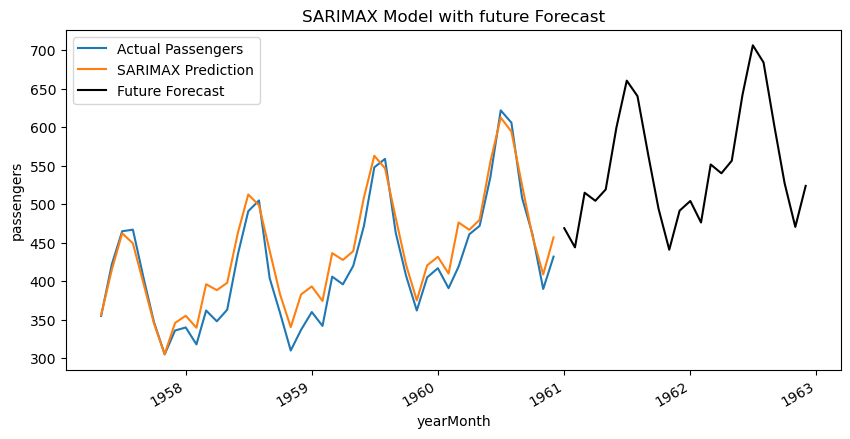

In [17]:
#Future Forecast using SARIMAX
future_dates = pd.DataFrame(pd.date_range(start = '1961-01-01',end = '1962-12-01',freq='MS'),columns=['Dates'])
future_dates.set_index('Dates',inplace=True)

future_forecast = model_sarimax_fit.predict(start=future_dates.index[0],end=future_dates.index[-1])
print(future_forecast)

#Plot Future Forecast
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index,y=airP['passengers'],label = 'Actual Passengers')
sns.lineplot(x=airP.index,y=airP['sarimaxPred'],label='SARIMAX Prediction')
future_forecast.plot(color='black',label='Future Forecast')
plt.title('SARIMAX Model with future Forecast')
plt.legend()
plt.show()

In [18]:
print("Values for Arima")
#Arima
print(mean_absolute_error(airP['passengers'],airP['arimaPred']))
print(mean_squared_error(airP['passengers'],airP['arimaPred']))
print(r2_score(airP['passengers'],airP['arimaPred']))

print("Values for Sarimax")
#Sarima
print(mean_absolute_error(airP['passengers'],airP['sarimaxPred']))
print(mean_squared_error(airP['passengers'],airP['sarimaxPred']))
print(r2_score(airP['passengers'],airP['sarimaxPred']))

Values for Arima
53.924279797677556
5039.614980797969
0.13765225988892726
Values for Sarimax
19.747205280285193
556.8162382552104
0.904721049813115


In [22]:
#Exercise : Do Time Series Analysis on onthly -cola-production-in-austr.csv (file in github)

df = pd.read_csv('monthly-cola-production-in-austr.csv')
print(df.head())

     Month  cola
0  1956-01  93.2
1  1956-02  96.0
2  1956-03  95.2
3  1956-04  77.1
4  1956-05  70.9
